# Exploring the NIST Chemistry WebBook

The NIST Chemistry WebBook provides thermochemical, thermophysical, and ion energetics data compiled by NIST under the Standard Reference Data Program.  
[Visit NIST Chemistry WebBook](https://webbook.nist.gov/chemistry/)

If you have not explored the NIST Chemistry WebBook before, take some time to visit the link above and explore the site. Try the following exercises:

## 1. Search by name for "caffeine"
   * View the 3D structure by selecting the "Javascript" link
   * Examine the phase change data
   * Examine the IR spectrum data
   * Examine the UV-Vis spectrum data

## 2. Search by molecular formula for "C12H22O11"
   * Select "sucrose"
   * View the 3D structure by selecting the "Javascript" link
   * Examine the phase change data
   * Examine the IR spectrum data
   * Examine the UV-Vis spectrum data

## Before you begin

**Purpose.** Explore an example of mining boiling-point data and the difference between a live data-collection workflow and a prepared, reusable dataset.

**Prepared-data setup.** Before class, manually copy `Compounds.parquet` and `CompoundData.parquet` from the shared Parquet-file directory into this `01_Structure_to_Boiling_Point` directory. The notebook reads those files from the same directory as the notebook.

**Live collection.** The live NIST cells contain the full collection code used to create the datasets. They make many requests and can take minutes to hours, so leave their `RUN_LIVE_...` switches set to `False` unless you are running the demonstration.

**Accessibility.** Each figure is followed by a caption that states its key interpretation; use the caption together with the plotted values and labels.


In [54]:
import sys
import tqdm
print(sys.executable)
print(tqdm.__version__)

C:\Users\stlma\miniforge3\envs\ci\python.exe
4.70.1


In [55]:
from pathlib import Path

# Keep prepared data with this notebook. Copy Compounds.parquet and
# CompoundData.parquet from the shared Parquet-file directory into this folder.
MODULE_WORKING_DIR = Path.cwd().resolve()

def data_path(filename: str) -> Path:
    candidate = MODULE_WORKING_DIR / filename
    if candidate.is_file():
        print(f"Using data file: {candidate}")
        return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Copy it from the shared Parquet-file directory "
        f"into this 01_Structure_to_Boiling_Point folder, then rerun this cell."
    )

def output_file(filename: str) -> Path:
    return MODULE_WORKING_DIR / filename


In [56]:
%matplotlib inline

In [57]:
# NISTChemPy 2.0 is installed by environment.yml. No inline installation is needed.

# Connecting to the NIST Chemistry WebBook

This notebook uses [NistChemPy](https://pypi.org/project/NistChemPy/) 2.0 to query individual NIST Chemistry WebBook pages. The course environment installs the package; after activating the `ci` environment, start JupyterLab normally.

NistChemPy 2.0 no longer distributes a bundled all-compounds table. The prepared Parquet files supplied with this course provide the reproducible dataset for modeling, while the short live-query examples below demonstrate the current WebBook interface.

In [58]:
import nistchempy as nist

# The delay is used by the optional live-collection cells to avoid rapid requests.
request_config = nist.RequestConfig(delay=3, max_attempts=3)
print(f"Using NistChemPy {nist.__version__}")

Using NistChemPy 2.0.0


<!-- che8615-clarity -->
### Start with a small data audit

**Purpose:** Connect to the WebBook interface and inspect what information is actually available.  
**Why it matters:** A model can only learn from fields that are present, sufficiently complete, and meaningful.  
**Key takeaway:** Before collecting thousands of records, verify the schema and ask which columns can support the scientific question.


In [59]:
# NistChemPy 2.0 does not bundle a WebBook-wide data table.
# Use the prepared course dataset for a reproducible audit instead.
import pandas as pd

df = pd.read_parquet(data_path('Compounds.parquet'))
print(f"Loaded {len(df):,} prepared compound records.")
display(df.head())

Using data file: C:\Users\stlma\Documents\MIZZOU\github\mizzou_atomistic_materials_analytics_fs2026\01_Structure_to_Boiling_Point\Compounds.parquet
Loaded 11,966 prepared compound records.


,ID,name,formula,mol_weight,inchi,inchi_key,cas_rn,mol2D,mol3D,cIR,...,cGC,cTG,cTC,cTP,cSO,cTR,cIE,cIC,cES,cDI
0,C100005,"Benzene, 1-chloro-4-nitro-",C6 H4 ClNO2,157.5540,InChI=1S/C6H4ClNO2/c7-5-1-3-6(4-2-5)8(9)10/h1-4H,CZGCEKJOLUNIFY-UHFFFAOYSA-N,100-00-5,True,True,True,...,True,False,True,True,False,True,True,True,False,False
1,C100016,p-Nitroaniline,C6 H6 N2 O2,138.1240,InChI=1S/C6H6N2O2/c7-5-1-3-6(4-2-5)8(9)10/h1-4...,TYMLOMAKGOJONV-UHFFFAOYSA-N,100-01-6,True,True,True,...,True,True,True,True,False,True,True,False,False,False
2,C100027,"Phenol, 4-nitro-",C6 H5 NO3,139.1088,"InChI=1S/C6H5NO3/c8-6-3-1-5(2-4-6)7(9)10/h1-4,8H",BTJIUGUIPKRLHP-UHFFFAOYSA-N,100-02-7,True,True,True,...,True,True,True,True,True,True,True,True,False,False
3,C1000506,N-butyl chlorodimethyl silane,C6 H15 ClSi,150.7220,"InChI=1S/C6H15ClSi/c1-4-5-6-8(2,3)7/h4-6H2,1-3H3",MXOSTENCGSDMRE-UHFFFAOYSA-N,1000-50-6,True,True,True,...,False,False,False,True,False,False,False,False,False,False
4,C100061,4-Acetylanisole,C9 H10 O2,150.1745,InChI=1S/C9H10O2/c1-7(10)8-3-5-9(11-2)6-4-8/h3...,NTPLXRHDUXRPNE-UHFFFAOYSA-N,100-06-1,True,True,True,...,True,False,True,True,False,False,True,False,False,False


# Boiling Point Prediction Based on Chemical Features

In this example, we want to predict the boiling point of a subset of molecules based on chemical features and the structure of the molecule.

The above list contains ions, heavy metals, etc., which we do not want to include in our training set.

Restricting the data can be done top-down using regular expressions on the molecular formula to mask the DataFrame, but enumerating all possible regular expressions may be arduous.


In [60]:
df.keys()

Index(['ID', 'name', 'formula', 'mol_weight', 'inchi', 'inchi_key', 'cas_rn',
       'mol2D', 'mol3D', 'cIR', 'cTZ', 'cMS', 'cUV', 'cGC', 'cTG', 'cTC',
       'cTP', 'cSO', 'cTR', 'cIE', 'cIC', 'cES', 'cDI'],
      dtype='object')

The prepared dataset includes `mol3D` links, which may support later structure-based modeling. The `cTG`, `cTC`, and related columns record WebBook sections that were available when the dataset was prepared. Use the command below to see the current NistChemPy search-filter names.


In [61]:
nist.print_search_parameters()

use_SI         :   Units for thermodynamic data, "SI" if True and "calories" if False
match_isotopes :   Exactly match the specified isotopes (formula search only)
allow_other    :   Allow elements not specified in formula (formula search only)
allow_extra    :   Allow more atoms of elements in formula than specified (formula search only)
no_ion         :   Exclude ions from the search (formula search only)
cTG            :   Gas phase thermochemistry data
cTC            :   Condensed phase thermochemistry data
cTP            :   Phase change data
cTR            :   Reaction thermochemistry data
cIE            :   Gas phase ion energetics data
cIC            :   Ion clustering data
cIR            :   IR Spectrum
cTZ            :   THz IR spectrum
cMS            :   Mass spectrum (electron ionization)
cUV            :   UV/Visible spectrum
cGC            :   Gas Chromatography
cES            :   Vibrational and/or electronic energy levels
cDI            :   Constants of diatomic molecul

In [62]:
#In this example, we want to collect
a=df[(df['cTP']==True)]
display(a)
len(a)

,ID,name,formula,mol_weight,inchi,inchi_key,cas_rn,mol2D,mol3D,cIR,...,cGC,cTG,cTC,cTP,cSO,cTR,cIE,cIC,cES,cDI
0,C100005,"Benzene, 1-chloro-4-nitro-",C6 H4 ClNO2,157.5540,InChI=1S/C6H4ClNO2/c7-5-1-3-6(4-2-5)8(9)10/h1-4H,CZGCEKJOLUNIFY-UHFFFAOYSA-N,100-00-5,True,True,True,...,True,False,True,True,False,True,True,True,False,False
1,C100016,p-Nitroaniline,C6 H6 N2 O2,138.1240,InChI=1S/C6H6N2O2/c7-5-1-3-6(4-2-5)8(9)10/h1-4...,TYMLOMAKGOJONV-UHFFFAOYSA-N,100-01-6,True,True,True,...,True,True,True,True,False,True,True,False,False,False
2,C100027,"Phenol, 4-nitro-",C6 H5 NO3,139.1088,"InChI=1S/C6H5NO3/c8-6-3-1-5(2-4-6)7(9)10/h1-4,8H",BTJIUGUIPKRLHP-UHFFFAOYSA-N,100-02-7,True,True,True,...,True,True,True,True,True,True,True,True,False,False
3,C1000506,N-butyl chlorodimethyl silane,C6 H15 ClSi,150.7220,"InChI=1S/C6H15ClSi/c1-4-5-6-8(2,3)7/h4-6H2,1-3H3",MXOSTENCGSDMRE-UHFFFAOYSA-N,1000-50-6,True,True,True,...,False,False,False,True,False,False,False,False,False,False
4,C100061,4-Acetylanisole,C9 H10 O2,150.1745,InChI=1S/C9H10O2/c1-7(10)8-3-5-9(11-2)6-4-8/h3...,NTPLXRHDUXRPNE-UHFFFAOYSA-N,100-06-1,True,True,True,...,True,False,True,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11961,C999780,"2-Pentyne, 4,4-dimethyl-",C7 H12,96.1702,"InChI=1S/C7H12/c1-5-6-7(2,3)4/h1-4H3",FOALCTWKQSWRST-UHFFFAOYSA-N,999-78-0,True,True,True,...,True,True,False,True,False,False,True,False,False,False
11962,C99989,"1,4-Benzenediamine, N,N-dimethyl-",C8 H12 N2,136.1943,InChI=1S/C8H12N2/c1-10(2)8-5-3-7(9)4-6-8/h3-6H...,BZORFPDSXLZWJF-UHFFFAOYSA-N,99-98-9,True,True,False,...,True,False,False,True,False,False,True,False,False,False
11963,C99990,"Benzene, 1-methyl-4-nitro-",C7 H7 NO2,137.1360,InChI=1S/C7H7NO2/c1-6-2-4-7(5-3-6)8(9)10/h2-5H...,ZPTVNYMJQHSSEA-UHFFFAOYSA-N,99-99-0,True,True,True,...,True,True,True,True,True,True,True,True,False,False
11964,C999906,Ethanethioic acid S-tert-butyl ester,C6 H12 OS,132.2240,"InChI=1S/C6H12OS/c1-5(7)8-6(2,3)4/h1-4H3",PJFHXBBYLAVSLJ-UHFFFAOYSA-N,999-90-6,True,True,False,...,True,False,False,True,False,True,False,False,False,False


11966

In [63]:
# A live query can filter WebBook search results with these parameters.
# The current API uses snake_case names such as no_ion and allow_other.
nist.print_search_parameters()

use_SI         :   Units for thermodynamic data, "SI" if True and "calories" if False
match_isotopes :   Exactly match the specified isotopes (formula search only)
allow_other    :   Allow elements not specified in formula (formula search only)
allow_extra    :   Allow more atoms of elements in formula than specified (formula search only)
no_ion         :   Exclude ions from the search (formula search only)
cTG            :   Gas phase thermochemistry data
cTC            :   Condensed phase thermochemistry data
cTP            :   Phase change data
cTR            :   Reaction thermochemistry data
cIE            :   Gas phase ion energetics data
cIC            :   Ion clustering data
cIR            :   IR Spectrum
cTZ            :   THz IR spectrum
cMS            :   Mass spectrum (electron ionization)
cUV            :   UV/Visible spectrum
cGC            :   Gas Chromatography
cES            :   Vibrational and/or electronic energy levels
cDI            :   Constants of diatomic molecul

In [64]:
# Search for nonionic compounds with IR, UV-vis, and phase-change data.
search = nist.run_search(
    'C10H*', 'formula',
    no_ion=True, allow_other=False, allow_extra=False,
    cIR=True, cUV=True, cTP=True,
    request_config=request_config,
)
print(search.search_parameters)

NistSearchParameters(use_SI=True, no_ion=True, cTP=True, cIR=True, cUV=True)


In [65]:
# The result stores IDs in compound_ids. The WebBook can truncate broad searches.
display(search.compound_ids[:10])

['C447530',
 'C612179',
 'C108576',
 'C2177471',
 'C105066',
 'C16520620',
 'C1005512',
 'C622764',
 'C26934612',
 'C2288188']

In [66]:
# lost=True indicates that the WebBook truncated a broad query.
print(f"Found {search.num_compounds} records; truncated by WebBook: {search.lost}")

Found 400 records; truncated by WebBook: True


In [67]:
# Live compound-ID collection
# This code demonstrates how to collect a broader list than one WebBook query
# can return. Set the switch to True only when running this demonstration.
RUN_LIVE_COMPOUND_COLLECTION = False

if RUN_LIVE_COMPOUND_COLLECTION:
    search_parameters = nist.NistSearchParameters(
        no_ion=True, allow_other=False, allow_extra=False, cTP=True
    )
    overflows = set()

    def collect_formula_matches(formula):
        result = nist.run_search(
            formula, 'formula', search_parameters=search_parameters,
            request_config=request_config,
        )
        if result.success:
            overflows.update(result.compound_ids)
        else:
            print(f"Search failed for {formula}: {result.message}")
        return result

    from tqdm.auto import tqdm

    for carbon in tqdm(range(20), desc='Collecting compound IDs', unit='carbon count'):
        result = collect_formula_matches(f'C{carbon}H*O*N*S*Cl*')
        if result.lost:
            for hydrogen in range(carbon*4):
                result = collect_formula_matches(f'C{carbon}H{hydrogen}O*N*S*Cl*')
                if result.lost:
                    print(f"WebBook still truncated C{carbon}H{hydrogen}O*N*S*Cl*.")

    live_ids = pd.DataFrame({'ID': sorted(overflows)})
    live_ids.to_parquet(output_file('LiveNISTCompoundIDs.parquet'), index=False)
    print(f"Saved {len(live_ids):,} live NIST IDs to LiveNISTCompoundIDs.parquet.")
else:
    print('Live ID collection is disabled. Set RUN_LIVE_COMPOUND_COLLECTION = True to run it.')


Live ID collection is disabled. Set RUN_LIVE_COMPOUND_COLLECTION = True to run it.


In [68]:
# Use IDs created by the optional live collection when available. Otherwise,
# continue with the prepared dataset that you copied into this directory.
live_ids_path = output_file('LiveNISTCompoundIDs.parquet')
if live_ids_path.is_file():
    overflow = pd.read_parquet(live_ids_path)['ID'].tolist()
    print(f"Loaded {len(overflow):,} IDs collected during the live demonstration.")
else:
    overflow = a['ID'].tolist()
    print(f"Using {len(overflow):,} IDs from Compounds.parquet.")

display(overflow[:10])

Loaded 12,344 IDs collected during the live demonstration.


['C100005',
 'C100016',
 'C100027',
 'C1000302',
 'C100046002',
 'C100061',
 'C1000631',
 'C100072',
 'C1000868',
 'C10008738']

In [69]:
# Compare the prepared phase-change dataset with IDs found by the live search.
prepared_ids = set(a['ID'])
live_ids = set(overflow)

union = sorted(prepared_ids | live_ids)
intersection = sorted(prepared_ids & live_ids)
live_only_ids = sorted(live_ids - prepared_ids)
prepared_only_ids = sorted(prepared_ids - live_ids)

comparison_df = pd.DataFrame({'ID': union})
comparison_df['in_prepared_dataset'] = comparison_df['ID'].isin(prepared_ids)
comparison_df['in_live_search'] = comparison_df['ID'].isin(live_ids)
comparison_df.to_parquet(
    output_file('PreparedVsLiveIDComparison.parquet'),
    index=False,
)

print(f"Prepared phase-change IDs: {len(prepared_ids):,}")
print(f"Live-search IDs: {len(live_ids):,}")
print(f"IDs in both sources: {len(intersection):,}")
print(f"Live-only IDs to evaluate: {len(live_only_ids):,}")
print(f"Prepared-only IDs not returned by this live search: {len(prepared_only_ids):,}")
print(f"Full union: {len(union):,} IDs")

Prepared phase-change IDs: 11,966
Live-search IDs: 12,344
IDs in both sources: 9,324
Live-only IDs to evaluate: 3,020
Prepared-only IDs not returned by this live search: 2,642
Full union: 14,986 IDs


In [70]:
# Enrich live-only IDs before filtering by 3D-structure availability.
# The prepared table cannot tell us whether a live-only ID has a 3D structure,
# so retrieve its current metadata from NIST and save it for future runs.
RUN_LIVE_METADATA_ENRICHMENT = False
LIVE_METADATA_LIMIT = None  # Use, for example, 25 for an in-class demonstration.
METADATA_FILENAME = 'LiveOnlyNISTMetadata.parquet'

metadata_path = output_file(METADATA_FILENAME)
metadata_request_config = nist.RequestConfig(delay=5, max_attempts=3)
bool_columns = df.select_dtypes(include='bool').columns.tolist()

if metadata_path.is_file():
    live_metadata_df = pd.read_parquet(metadata_path)
else:
    live_metadata_df = pd.DataFrame(columns=df.columns)

checked_live_ids = set(live_metadata_df['ID'].dropna())
ids_to_enrich = [
    compound_id
    for compound_id in live_only_ids
    if compound_id not in checked_live_ids
]

if LIVE_METADATA_LIMIT is not None:
    ids_to_enrich = ids_to_enrich[:LIVE_METADATA_LIMIT]

def compound_to_prepared_row(compound):
    """Convert a current NistChemPy compound record to the prepared-table schema."""
    row = {column: pd.NA for column in df.columns}
    row.update({
        'ID': compound.ID,
        'name': compound.name,
        'formula': compound.formula,
        'mol_weight': compound.mol_weight,
        'inchi': compound.inchi,
        'inchi_key': compound.inchi_key,
        'cas_rn': compound.cas_rn,
        'mol2D': 'mol2D' in compound.mol_refs,
        'mol3D': 'mol3D' in compound.mol_refs,
    })
    for section in (
        'cIR', 'cTZ', 'cMS', 'cUV', 'cGC', 'cTG', 'cTC', 'cTP',
        'cSO', 'cTR', 'cIE', 'cIC', 'cES', 'cDI',
    ):
        row[section] = section in compound.data_refs
    return row

if RUN_LIVE_METADATA_ENRICHMENT:
    from tqdm.notebook import tqdm

    new_rows = []
    failed_metadata_ids = []
    for compound_id in tqdm(
        ids_to_enrich,
        desc='Checking live-only NIST IDs for 3D structures',
        unit='compound',
    ):
        try:
            compound = nist.get_compound(
                compound_id,
                request_config=metadata_request_config,
            )
            if compound is not None:
                new_rows.append(compound_to_prepared_row(compound))
        except Exception as error:
            failed_metadata_ids.append((compound_id, str(error)))

    if new_rows:
        new_metadata_df = pd.DataFrame(new_rows)
        if live_metadata_df.empty:
            live_metadata_df = new_metadata_df
        else:
            live_metadata_df = pd.concat(
                [live_metadata_df, new_metadata_df],
                ignore_index=True,
            )
        live_metadata_df = live_metadata_df.drop_duplicates(
            subset='ID',
            keep='last',
        )
        live_metadata_df.to_parquet(metadata_path, index=False)

    print(f"Saved metadata for {len(live_metadata_df):,} live-only IDs.")
    print(f"Metadata requests that failed: {len(failed_metadata_ids):,}")
else:
    print(
        f"Live metadata enrichment is disabled; {len(ids_to_enrich):,} live-only IDs "
        "are still pending a 3D-availability check."
    )

# Retain the complete union. Reindexing adds pending live-only IDs without
# using an all-missing placeholder table, which keeps the table dtypes intact.
prepared_rows = a.copy()
prepared_rows[bool_columns] = prepared_rows[bool_columns].astype('boolean')
prepared_rows['record_source'] = 'prepared'

live_metadata_rows = live_metadata_df.copy()
updated_prepared_df = prepared_rows.set_index('ID')
if not live_metadata_rows.empty:
    live_metadata_rows[bool_columns] = live_metadata_rows[bool_columns].astype('boolean')
    live_metadata_rows['record_source'] = 'live_metadata'
    updated_prepared_df = updated_prepared_df.combine_first(
        live_metadata_rows.set_index('ID')
    )

updated_prepared_df = (
    updated_prepared_df
    .reindex(sorted(set(a['ID']) | set(live_only_ids)))
    .rename_axis('ID')
    .reset_index()
)
updated_prepared_df['record_source'] = updated_prepared_df['record_source'].fillna(
    'live_metadata_pending'
)
enriched_live_ids = set(live_metadata_rows['ID'].dropna())
pending_live_ids = sorted(set(live_only_ids) - enriched_live_ids)
updated_prepared_df.to_parquet(
    output_file('Compounds_updated_from_live.parquet'),
    index=False,
)

# Use only the verified 3D subset for the later structure-based workflow.
# Pending live-only records stay in Compounds_updated_from_live.parquet.
mol3d_available = updated_prepared_df['mol3D'].astype('boolean').fillna(False)
filtered_df = updated_prepared_df[mol3d_available].copy()
filtered_df = filtered_df.reset_index(drop=True)
print(f"Full union retained in updated index: {len(updated_prepared_df):,}")
print(f"Live-only IDs pending metadata: {len(pending_live_ids):,}")
print(f"Verified records with 3D structures: {len(filtered_df):,}")

Live metadata enrichment is disabled; 3,020 live-only IDs are still pending a 3D-availability check.
Full union retained in updated index: 14,986
Live-only IDs pending metadata: 3,020
Verified records with 3D structures: 11,966


In [71]:
# PyArrow reads and writes efficient Parquet tables. It is already installed by environment.yml.
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [72]:
# Save the verified 3D subset separately. Do not overwrite the prepared
# Compounds.parquet file that was copied from the shared Parquet directory.
path = output_file('Compounds_with_3D_updated_from_live.parquet')
filtered_df.to_parquet(path, index=False)
print(f"Saved {len(filtered_df):,} records to {path.name}.")

Saved 11,966 records to Compounds_with_3D_updated_from_live.parquet.


<!-- che8615-clarity -->
### Use the prepared dataset for the course workflow

**Purpose:** Load the supplied, reproducible collection instead of relying on a long live scrape.  
**Why it matters:** External websites change and large collection jobs can fail; reproducible data lets the class focus on analysis.  
**Key takeaway:** Treat live acquisition as a useful method to understand, but treat the prepared Parquet file as the stable starting point for modeling.


In [73]:
import pandas as pd

updated_3d_path = output_file('Compounds_with_3D_updated_from_live.parquet')
if updated_3d_path.is_file():
    filtered_df = pd.read_parquet(updated_3d_path)
    print(f'Loaded {len(filtered_df):,} updated 3D-ready compound records.')
else:
    filtered_df = pd.read_parquet(data_path('Compounds.parquet'))
    print(f'Loaded {len(filtered_df):,} prepared compound records.')

display(filtered_df.head())

Loaded 11,966 updated 3D-ready compound records.


,ID,name,formula,mol_weight,inchi,inchi_key,cas_rn,mol2D,mol3D,cIR,...,cTG,cTC,cTP,cSO,cTR,cIE,cIC,cES,cDI,record_source
0,C100005,"Benzene, 1-chloro-4-nitro-",C6 H4 ClNO2,157.5540,InChI=1S/C6H4ClNO2/c7-5-1-3-6(4-2-5)8(9)10/h1-4H,CZGCEKJOLUNIFY-UHFFFAOYSA-N,100-00-5,True,True,True,...,False,True,True,False,True,True,True,False,False,prepared
1,C100016,p-Nitroaniline,C6 H6 N2 O2,138.1240,InChI=1S/C6H6N2O2/c7-5-1-3-6(4-2-5)8(9)10/h1-4...,TYMLOMAKGOJONV-UHFFFAOYSA-N,100-01-6,True,True,True,...,True,True,True,False,True,True,False,False,False,prepared
2,C100027,"Phenol, 4-nitro-",C6 H5 NO3,139.1088,"InChI=1S/C6H5NO3/c8-6-3-1-5(2-4-6)7(9)10/h1-4,8H",BTJIUGUIPKRLHP-UHFFFAOYSA-N,100-02-7,True,True,True,...,True,True,True,True,True,True,True,False,False,prepared
3,C1000506,N-butyl chlorodimethyl silane,C6 H15 ClSi,150.7220,"InChI=1S/C6H15ClSi/c1-4-5-6-8(2,3)7/h4-6H2,1-3H3",MXOSTENCGSDMRE-UHFFFAOYSA-N,1000-50-6,True,True,True,...,False,False,True,False,False,False,False,False,False,prepared
4,C100061,4-Acetylanisole,C9 H10 O2,150.1745,InChI=1S/C9H10O2/c1-7(10)8-3-5-9(11-2)6-4-8/h3...,NTPLXRHDUXRPNE-UHFFFAOYSA-N,100-06-1,True,True,True,...,False,True,True,False,False,True,False,False,False,prepared


In [74]:
overflows=list(filtered_df['ID'])
print(overflows[1:10])
print(len(overflows))

['C100016', 'C100027', 'C1000506', 'C100061', 'C1000631', 'C100072', 'C1000868', 'C10008738', 'C1000879']
11966


In [75]:
#Now we need to download the boiling point data for each compound. Let's start by doing this for one compound:

ID=filtered_df['ID'][0]
print(ID)

C100005


In [76]:
# Fetch compound metadata from the current NistChemPy API.
chem = nist.get_compound(ID, request_config=request_config)
if chem is None:
    raise LookupError(f"No unique NIST Chemistry WebBook record found for {ID}.")

cas = chem.cas_rn
MW = chem.mol_weight
phase_change_url = chem.data_refs.get('cTP')

print(f"CAS Number: {cas}")
print(f"Molecular Weight: {MW} g/mol")
if phase_change_url:
    print(f"Phase-change data: {phase_change_url}")
else:
    print("No phase-change data page is available for this compound.")


CAS Number: 100-00-5
Molecular Weight: 157.554 g/mol
Phase-change data: https://webbook.nist.gov/cgi/cbook.cgi?ID=C100005&Mask=4#Thermo-Phase


In [77]:
# PubChemPy retrieves chemical properties and structures from PubChem. It is already installed by environment.yml.
%pip install pubchempy

Note: you may need to restart the kernel to use updated packages.


In [78]:
# NistChemPy exposes the phase-change page URL, but boiling-point values are
# not a direct NistChemPy record type. Parse only rows explicitly labeled T_boil.
import re
import time
import requests
from bs4 import BeautifulSoup

def get_boiling_point(phase_change_url):
    if not phase_change_url:
        return None
    response = requests.get(phase_change_url, timeout=30)
    response.raise_for_status()
    time.sleep(request_config.delay)
    soup = BeautifulSoup(response.text, 'html.parser')
    for row in soup.select('tr'):
        cells = row.find_all(['th', 'td'])
        if not cells or 'Tboil' not in cells[0].get_text('', strip=True):
            continue
        match = re.search(r'[-+]?\d*\.?\d+', cells[1].get_text(' ', strip=True))
        if match:
            return float(match.group())
    return None

BP = get_boiling_point(phase_change_url)
print(f"Boiling point: {BP} K" if BP is not None else "No boiling point was found.")

Boiling point: 515.2 K


In [79]:
# Live boiling-point collection
# This is the full collection workflow used to create a new teaching dataset.
# It can take hours because each compound requires several polite web requests.
RUN_LIVE_BOILING_POINT_COLLECTION = False

if RUN_LIVE_BOILING_POINT_COLLECTION:
    import pubchempy
    from tqdm.auto import tqdm

    records = []
    for compound_id in tqdm(filtered_df['ID'], desc='Collecting boiling points', unit='compound'):
        try:
            chem = nist.get_compound(compound_id, request_config=request_config)
            if chem is None:
                continue

            phase_change_url = chem.data_refs.get('cTP')
            BP = get_boiling_point(phase_change_url)
            if BP is None:
                continue

            mol3D = chem.get_mol3D()
            pubchem_records = pubchempy.get_compounds(chem.cas_rn, 'name')
            SMILES = pubchem_records[0].canonical_smiles if pubchem_records else None
            records.append({
                'CAS': chem.cas_rn,
                'MW': chem.mol_weight,
                'BP': BP,
                'SMILES': SMILES,
                'mol3D': mol3D,
            })
        except Exception as error:
            print(f"Skipping {compound_id}: {error}")

    LiveCompoundData = pd.DataFrame(records)
    LiveCompoundData.to_parquet(output_file('LiveCompoundData.parquet'), index=False)
    print(f"Saved {len(LiveCompoundData):,} live records to LiveCompoundData.parquet.")
else:
    print('Live boiling-point collection is disabled. Set RUN_LIVE_BOILING_POINT_COLLECTION = True to run it.')


Live boiling-point collection is disabled. Set RUN_LIVE_BOILING_POINT_COLLECTION = True to run it.


In [80]:
import pandas as pd
CompoundData = pd.read_parquet(data_path('CompoundData.parquet'))
print(f'Loaded {len(CompoundData):,} records.')
display(CompoundData.head())

Using data file: C:\Users\stlma\Documents\MIZZOU\github\mizzou_atomistic_materials_analytics_fs2026\01_Structure_to_Boiling_Point\CompoundData.parquet
Loaded 3,541 records.


,CAS,MW,BP,SMILES,mol3D
0,999-90-6,132.2240,405.0,CC(=O)SC(C)(C)C,\r\n NIST 06261404023D 1 1.00000 -709.2...
1,99-98-9,136.1943,536.2,CN(C)C1=CC=C(C=C1)N,\r\n NIST 07201406313D 1 1.00000 -421.5...
2,999-78-0,96.1702,356.0,CC#CC(C)(C)C,\r\n NIST 07011509563D 1 1.00000 -273.9...
3,99-97-8,135.2062,484.2,CC1=CC=C(C=C1)N(C)C,"Benzenamine, N,N,4-trimethyl-\r\n NIST 062..."
4,99-94-5,136.1479,547.7,CC1=CC=C(C=C1)C(=O)O,"Benzoic acid, 4-methyl-\r\n NIST 070113222..."


In [81]:
CompoundData

,CAS,MW,BP,SMILES,mol3D
0,999-90-6,132.2240,405.00,CC(=O)SC(C)(C)C,\r\n NIST 06261404023D 1 1.00000 -709.2...
1,99-98-9,136.1943,536.20,CN(C)C1=CC=C(C=C1)N,\r\n NIST 07201406313D 1 1.00000 -421.5...
2,999-78-0,96.1702,356.00,CC#CC(C)(C)C,\r\n NIST 07011509563D 1 1.00000 -273.9...
3,99-97-8,135.2062,484.20,CC1=CC=C(C=C1)N(C)C,"Benzenamine, N,N,4-trimethyl-\r\n NIST 062..."
4,99-94-5,136.1479,547.70,CC1=CC=C(C=C1)C(=O)O,"Benzoic acid, 4-methyl-\r\n NIST 070113222..."
...,...,...,...,...,...
3536,100-07-2,170.5930,417.00,COC1=CC=C(C=C1)C(=O)Cl,\r\n NIST 06241419033D 1 1.00000 -919.7...
3537,1000-63-1,130.2279,397.15,CCCCOC(C)(C)C,\r\n NIST 07011503513D 1 1.00000 -390.9...
3538,100-06-1,150.1745,531.20,CC(=O)C1=CC=C(C=C1)OC,\r\n NIST 07011513463D 1 1.00000 -499.4...
3539,100-02-7,139.1088,552.20,C1=CC(=CC=C1[N+](=O)[O-])O,\r\n NIST 06181406493D 1 1.00000 -511.9...


In [82]:
# Seaborn provides statistical plotting tools. It is already installed by environment.yml.
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


<!-- che8615-clarity -->
### Inspect before modeling

**Purpose:** Visualize distributions and relationships in the cleaned boiling-point table.  
**Why it matters:** Plots reveal range, skew, outliers, and possible relationships before a model can hide those issues behind a score.  
**Key takeaway:** Use visualization to decide what needs cleaning, scaling, or a more thoughtful representation.


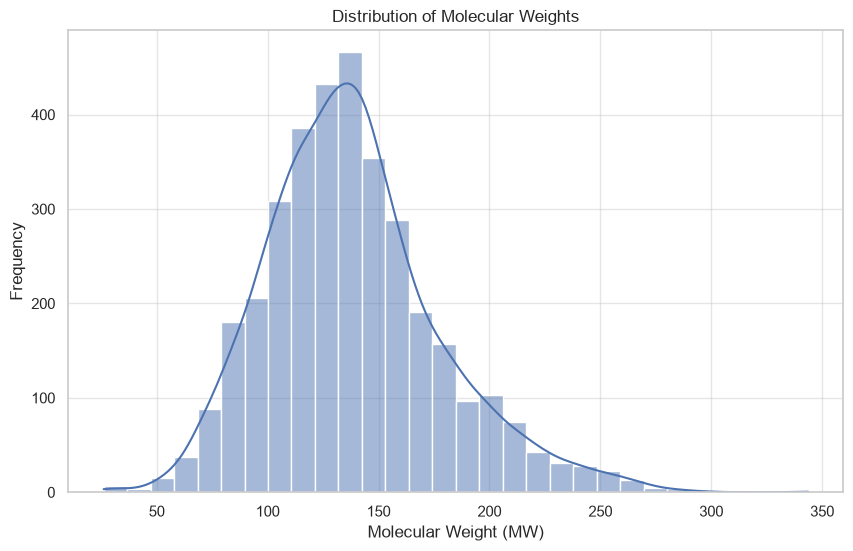

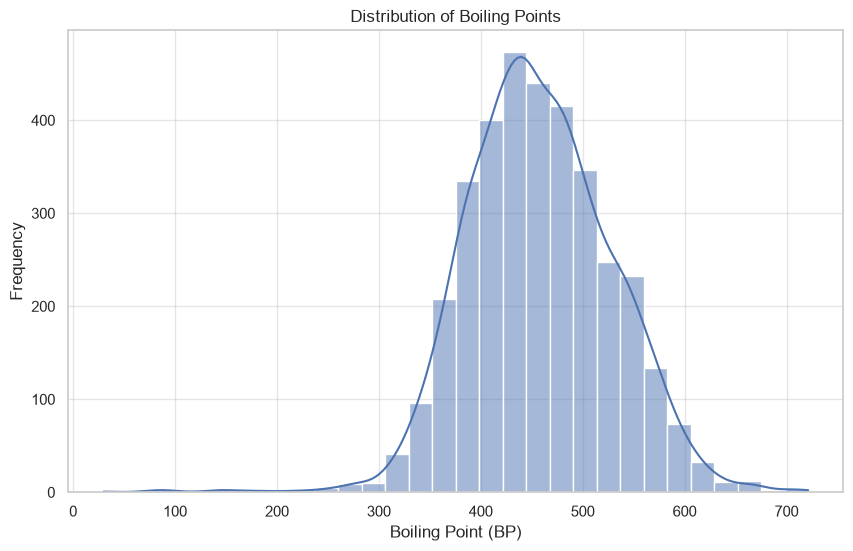

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure seaborn styles are used for the plots
sns.set(style="whitegrid")

# 1. Distribution of Molecular Weights (MW)
plt.figure(figsize=(10, 6))
sns.histplot(CompoundData['MW'], bins=30, kde=True)
plt.title('Distribution of Molecular Weights')
plt.xlabel('Molecular Weight (MW)')
plt.ylabel('Frequency')
plt.show()

# 2. Distribution of Boiling Points (BP)
plt.figure(figsize=(10, 6))
sns.histplot(CompoundData['BP'], bins=30, kde=True)
plt.title('Distribution of Boiling Points')
plt.xlabel('Boiling Point (BP)')
plt.ylabel('Frequency')
plt.show()

**Figure description.** Two separate histograms show frequency on the vertical axis. Molecular weight spans roughly 26–344 g/mol; boiling point spans roughly 30–721 K, with most observations concentrated away from the extremes.

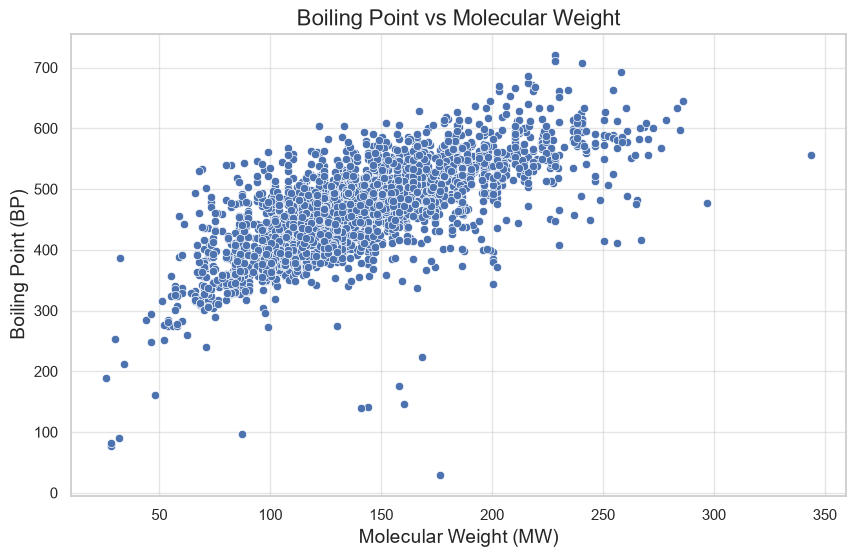

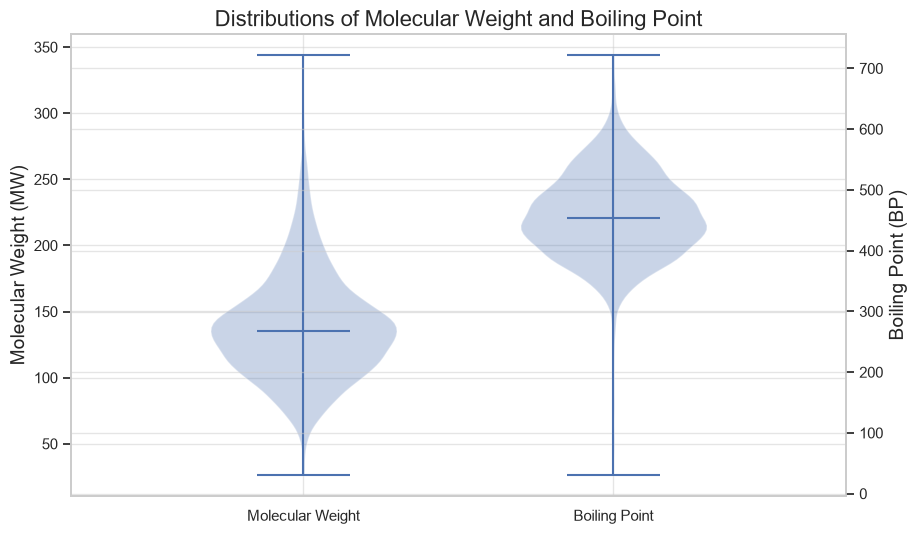

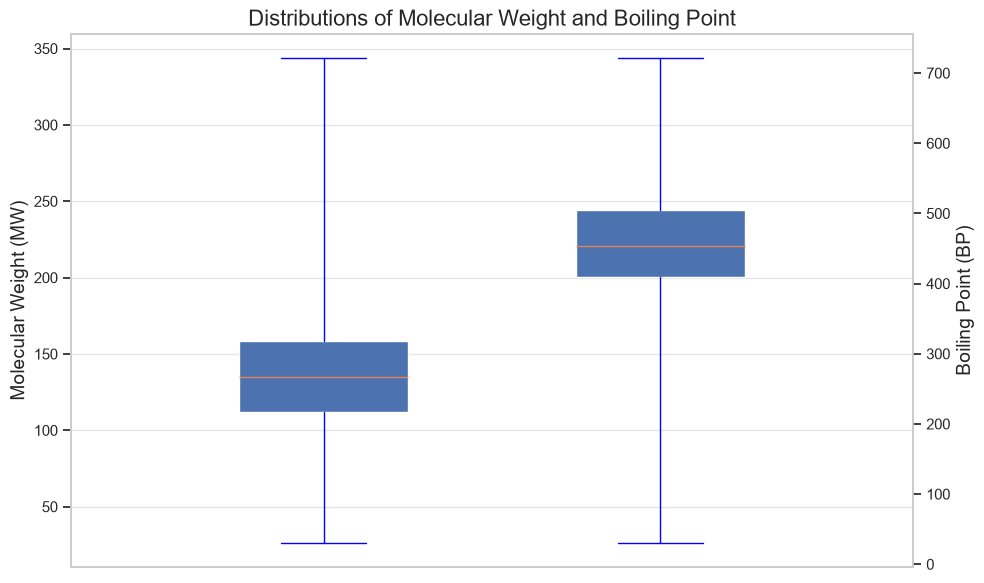

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure seaborn styles are applied
sns.set(style="whitegrid")

# Filter the CompoundData to exclude rows with missing values in 'BP' or 'MW'
filtered_data = CompoundData.dropna(subset=['BP', 'MW'])

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MW', y='BP', data=filtered_data)

# Add titles and labels
plt.title('Boiling Point vs Molecular Weight', fontsize=16)
plt.xlabel('Molecular Weight (MW)', fontsize=14)
plt.ylabel('Boiling Point (BP)', fontsize=14)

# Show the plot
plt.show()

# Violin plots:

# Create figure and left axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Create right axis
ax2 = ax1.twinx()

# Molecular weight violin on the left
ax1.violinplot(
    filtered_data['MW'],
    positions=[0],
    widths=0.6,
    showmeans=False,
    showmedians=True
)

# Boiling point violin on the right
ax2.violinplot(
    filtered_data['BP'],
    positions=[1],
    widths=0.6,
    showmeans=False,
    showmedians=True
)

# Axis labels
ax1.set_ylabel('Molecular Weight (MW)', fontsize=14)
ax2.set_ylabel('Boiling Point (BP)', fontsize=14)

# X-axis labels
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Molecular Weight', 'Boiling Point'])

# Make both axes use the same x-range
ax1.set_xlim(-0.75, 1.75)
ax2.set_xlim(-0.75, 1.75)

# Title
plt.title('Distributions of Molecular Weight and Boiling Point', fontsize=16)

plt.savefig("violinPlot.png")
plt.show()



# Boxplots:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.boxplot(
    filtered_data['MW'],
    positions=[0],
    widths=0.5,
    patch_artist=True,
    showfliers=False,
    whis=(0, 100),
    whiskerprops=dict(color='blue'),
    capprops=dict(color='blue')
)

ax2.boxplot(
    filtered_data['BP'],
    positions=[1],
    widths=0.5,
    patch_artist=True,
    showfliers=False,
    whis=(0, 100),
    whiskerprops=dict(color='blue'),
    capprops=dict(color='blue')
)

ax1.set_ylabel('Molecular Weight (MW)', fontsize=14)
ax2.set_ylabel('Boiling Point (BP)', fontsize=14)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Molecular Weight', 'Boiling Point'])
ax2.set_xticks([])

ax1.set_xlim(-0.75, 1.75)
ax2.set_xlim(-0.75, 1.75)

ax2.grid(False)

plt.title('Distributions of Molecular Weight and Boiling Point', fontsize=16)
plt.tight_layout()
plt.savefig("boxPlot.png")
plt.show()

**Figure description.** A scatter plot places molecular weight on the horizontal axis and boiling point on the vertical axis. The cloud rises from lower left to upper right, while substantial vertical spread remains at similar molecular weights.

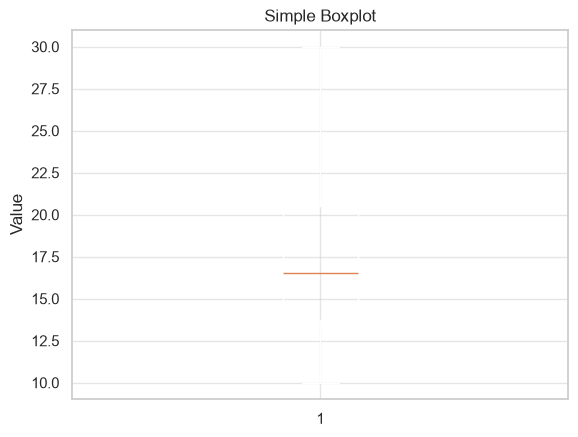

In [91]:
import matplotlib.pyplot as plt

# Simple example dataset
data = [10, 12, 13, 14, 15, 16, 17, 18, 20, 22, 25, 30]

# Make boxplot
plt.boxplot(data)

plt.title("Simple Boxplot")
plt.ylabel("Value")

plt.show()

In [85]:
# RDKit represents molecules and computes chemical features. It is already installed by environment.yml.
%pip install rdkit

Note: you may need to restart the kernel to use updated packages.


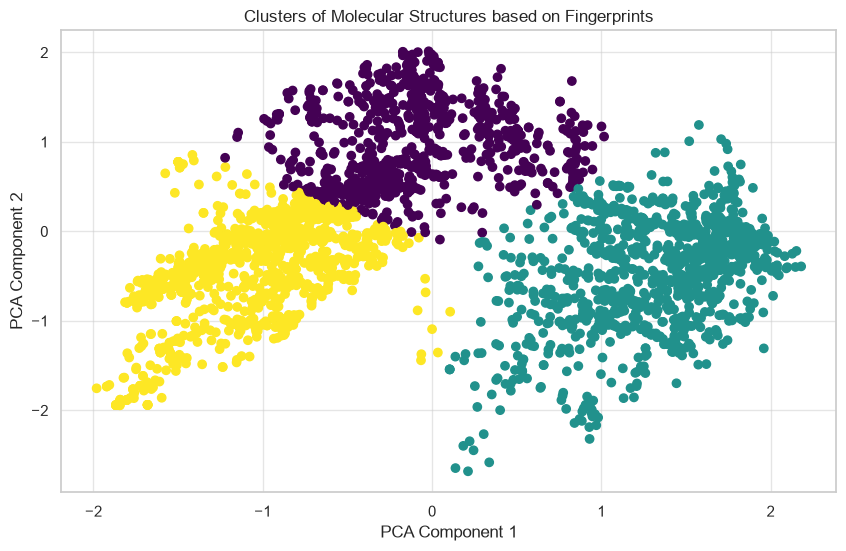

In [86]:
#https://github.com/rdkit/rdkit/tree/master/Docs/Notebooks

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Generate molecular fingerprints
fingerprints = []
for smiles in CompoundData['SMILES'].dropna():
    mol = Chem.MolFromSmiles(smiles)
    mg = rdFingerprintGenerator.GetMorganGenerator(radius = 2)
    fp = mg.GetFingerprint(mol)
    fingerprints.append(fp)

# Perform PCA for dimensionality reduction
pca = PCA(n_components=2)
fingerprints_2d = pca.fit_transform(fingerprints)

# Perform KMeans clustering
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(fingerprints_2d)

# Visualize clusters in 2D
plt.figure(figsize=(10, 6))
plt.scatter(fingerprints_2d[:, 0], fingerprints_2d[:, 1], c=labels, cmap='viridis')
plt.title('Clusters of Molecular Structures based on Fingerprints')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


**Figure description.** A two-dimensional scatter plot shows one molecule per point on two reduced representation components. Colors indicate assigned cluster labels; separated point clouds represent groups with similar structural fingerprints.